
# Taller de Evaluación Comparativa de Modelos de Lenguaje (LLMs)

## Guía de trabajo

Este documento constituye la guía de referencia para el taller de evaluación comparativa de modelos de lenguaje de gran escala (LLMs). Su propósito es proporcionar una infraestructura de código reutilizable que permita a los participantes cargar distintos modelos —locales y provistos mediante API— y medir de forma sistemática criterios de velocidad, calidad de respuesta y costo.

### Objetivos de aprendizaje

1. Comprender las diferencias operativas entre modelos ejecutados localmente y modelos consumidos mediante API.
2. Diseñar y ejecutar una metodología de evaluación comparativa (benchmarking) reproducible.
3. Cuantificar el desempeño de un modelo en términos de latencia, throughput, calidad de respuesta y costo.
4. Interpretar los resultados obtenidos para fundamentar una decisión de selección de modelo según un caso de uso específico.

### Estructura del documento

1. Configuración del entorno de trabajo.
2. Registro de modelos a evaluar.
3. Definición de la batería de instrucciones (prompts) de prueba.
4. Infraestructura de ejecución y medición (harness de benchmarking).
5. Ejecución de las pruebas.
6. Evaluación de calidad de las respuestas.
7. Consolidación y visualización de resultados.
8. Preguntas de análisis y discusión.
9. Anexo: extensión de la infraestructura a proveedores adicionales.

### Advertencia sobre el modo de ejecución

Este notebook incluye un **modo de simulación**, activado por defecto, que genera datos sintéticos de latencia, longitud de respuesta y costo cuando no se dispone de acceso a un servidor Ollama local o a credenciales de API. Este modo permite validar el funcionamiento completo de la infraestructura sin dependencias externas. Para la ejecución real durante el taller, el modo de simulación deberá desactivarse conforme a las instrucciones de la Sección 1.



---
## 1. Configuración del entorno de trabajo

### 1.1 Requisitos

Para la ejecución con modelos reales, se requiere lo siguiente:

**Modelos locales (mediante Ollama)**

- Instalación de Ollama desde el sitio oficial (ollama.com).
- Descarga de los modelos a evaluar mediante el comando `ollama pull <nombre_del_modelo>` (por ejemplo, `ollama pull llama3.2`, `ollama pull phi3`, `ollama pull gemma2`).
- El servicio de Ollama debe encontrarse en ejecución y accesible en `http://localhost:11434`.

**Modelos mediante API**

- Credenciales activas para los proveedores a evaluar (por ejemplo, OpenAI, Anthropic, Google).
- Las claves de API deben definirse como variables de entorno (`OPENAI_API_KEY`, `ANTHROPIC_API_KEY`, `GOOGLE_API_KEY`), evitando en todo momento incluirlas de forma literal en el código fuente.
- Instalación de las bibliotecas cliente correspondientes (`pip install openai anthropic google-generativeai`).

### 1.2 Activación del modo de ejecución real

La variable `SIMULATION_MODE`, definida en la celda de configuración siguiente, controla el comportamiento del harness:

- `SIMULATION_MODE = True`: las funciones de consulta generan respuestas sintéticas. No se requiere Ollama ni credenciales de API.
- `SIMULATION_MODE = False`: las funciones de consulta invocan los servicios reales. Se requiere que los requisitos de la sección 1.1 estén satisfechos.

Se recomienda validar la totalidad del flujo de trabajo en modo de simulación antes de proceder con la ejecución real.


In [1]:

import os
import time
import json
import math
import random
import statistics
from dataclasses import dataclass, field
from typing import Optional

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# Parámetro de control del modo de ejecución
# ------------------------------------------------------------
SIMULATION_MODE = True

# Intentos de importación de bibliotecas cliente opcionales.
# La ausencia de alguna de estas bibliotecas no interrumpe la ejecución
# del notebook; simplemente restringe el modo real a los proveedores disponibles.
try:
    import requests
    OLLAMA_AVAILABLE = True
except ImportError:
    OLLAMA_AVAILABLE = False

try:
    import openai
    OPENAI_LIB_AVAILABLE = True
except ImportError:
    OPENAI_LIB_AVAILABLE = False

try:
    import anthropic
    ANTHROPIC_LIB_AVAILABLE = True
except ImportError:
    ANTHROPIC_LIB_AVAILABLE = False

random.seed(42)
np.random.seed(42)

print(f"Modo de simulación activo: {SIMULATION_MODE}")
print(f"Cliente HTTP disponible (requerido para Ollama): {OLLAMA_AVAILABLE}")
print(f"Biblioteca de OpenAI disponible: {OPENAI_LIB_AVAILABLE}")
print(f"Biblioteca de Anthropic disponible: {ANTHROPIC_LIB_AVAILABLE}")


Modo de simulación activo: True
Cliente HTTP disponible (requerido para Ollama): True
Biblioteca de OpenAI disponible: False
Biblioteca de Anthropic disponible: False



---
## 2. Registro de modelos a evaluar

Cada modelo se define mediante una estructura que especifica su proveedor, el identificador exacto requerido por la API o por Ollama, y los costos de referencia por token. Los valores de costo incluidos a continuación son **ilustrativos**; cada equipo de trabajo debe verificar y actualizar dichos valores consultando la documentación de precios vigente del proveedor correspondiente antes de emplear estos datos en un análisis definitivo.

El campo `perfil_simulado` se utiliza exclusivamente en modo de simulación, y define de forma aproximada la velocidad y la calidad relativa esperadas del modelo, con el propósito de generar datos sintéticos coherentes.


In [2]:

@dataclass
class ModeloLLM:
    nombre: str                     # identificador visible en los reportes
    proveedor: str                  # "ollama" | "openai" | "anthropic" | "google"
    identificador_api: str          # nombre exacto exigido por el proveedor
    costo_entrada_usd_1k: float     # costo de referencia por 1000 tokens de entrada
    costo_salida_usd_1k: float      # costo de referencia por 1000 tokens de salida
    perfil_simulado: dict = field(default_factory=dict)  # solo para SIMULATION_MODE

# Registro de modelos. Modificar, añadir o eliminar entradas según
# la disponibilidad de modelos y credenciales del grupo de trabajo.
REGISTRO_MODELOS = [
    ModeloLLM(
        nombre="Llama 3.2 (1B, local)",
        proveedor="ollama",
        identificador_api="llama3.2:1b",
        costo_entrada_usd_1k=0.0,
        costo_salida_usd_1k=0.0,
        perfil_simulado={"latencia_base_s": 0.4, "tokens_por_s": 60, "calidad_media": 3.0, "calidad_desv": 0.6},
    ),
    ModeloLLM(
        nombre="Llama 3.2 (3B, local)",
        proveedor="ollama",
        identificador_api="llama3.2:3b",
        costo_entrada_usd_1k=0.0,
        costo_salida_usd_1k=0.0,
        perfil_simulado={"latencia_base_s": 0.8, "tokens_por_s": 40, "calidad_media": 3.6, "calidad_desv": 0.5},
    ),
    ModeloLLM(
        nombre="GPT-4o mini (API)",
        proveedor="openai",
        identificador_api="gpt-4o-mini",
        costo_entrada_usd_1k=0.00015,
        costo_salida_usd_1k=0.0006,
        perfil_simulado={"latencia_base_s": 0.9, "tokens_por_s": 55, "calidad_media": 4.1, "calidad_desv": 0.4},
    ),
    ModeloLLM(
        nombre="Claude Haiku (API)",
        proveedor="anthropic",
        identificador_api="claude-haiku-4-5",
        costo_entrada_usd_1k=0.001,
        costo_salida_usd_1k=0.005,
        perfil_simulado={"latencia_base_s": 0.7, "tokens_por_s": 65, "calidad_media": 4.2, "calidad_desv": 0.35},
    ),
]

tabla_modelos = pd.DataFrame([
    {
        "Modelo": m.nombre,
        "Proveedor": m.proveedor,
        "ID API": m.identificador_api,
        "Costo entrada (USD/1K tok)": m.costo_entrada_usd_1k,
        "Costo salida (USD/1K tok)": m.costo_salida_usd_1k,
    }
    for m in REGISTRO_MODELOS
])
tabla_modelos


,Modelo,Proveedor,ID API,Costo entrada (USD/1K tok),Costo salida (USD/1K tok)
0,"Llama 3.2 (1B, local)",ollama,llama3.2:1b,0.00000,0.0000
1,"Llama 3.2 (3B, local)",ollama,llama3.2:3b,0.00000,0.0000
2,GPT-4o mini (API),openai,gpt-4o-mini,0.00015,0.0006
3,Claude Haiku (API),anthropic,claude-haiku-4-5,0.00100,0.0050



---
## 3. Definición de la batería de instrucciones (prompts) de prueba

La validez de una evaluación comparativa depende de que todos los modelos sean sometidos exactamente a las mismas instrucciones, en las mismas condiciones. Se recomienda incluir tareas de distinta naturaleza, con el fin de observar el desempeño de cada modelo en diferentes tipos de razonamiento.

La estructura siguiente organiza las instrucciones por categoría. Cada categoría admite una función de verificación automática cuando la tarea posee una respuesta objetivamente correcta (por ejemplo, un resultado numérico), lo cual permite complementar la evaluación humana con una medición objetiva de exactitud.


In [3]:

@dataclass
class PromptPrueba:
    id_prompt: str
    categoria: str          # "matematica" | "codigo" | "resumen" | "razonamiento" | "conocimiento_factual" | "creatividad"
    texto: str
    respuesta_esperada: Optional[str] = None  # utilizada por la verificación automática, cuando aplica

BATERIA_PROMPTS = [
    PromptPrueba("mat_01", "matematica",
                 "Un tren viaja a 80 km/h durante 2.5 horas. Calcule la distancia recorrida en kilómetros. Responda únicamente con el número.",
                 respuesta_esperada="200"),
    PromptPrueba("mat_02", "matematica",
                 "Calcule 17 multiplicado por 23. Responda únicamente con el número.",
                 respuesta_esperada="391"),
    PromptPrueba("cod_01", "codigo",
                 "Escriba una función en Python llamada es_primo(n) que retorne True si n es un número primo y False en caso contrario."),
    PromptPrueba("res_01", "resumen",
                 "Resuma en un máximo de dos oraciones el siguiente texto: 'La fotosíntesis es el proceso mediante el cual las plantas, algas y algunas bacterias convierten la energía luminosa en energía química. Este proceso ocurre principalmente en los cloroplastos, donde la clorofila captura la luz solar. Como resultado, se produce glucosa y se libera oxígeno como subproducto, siendo este último esencial para la respiración de la mayoría de los seres vivos.'"),
    PromptPrueba("raz_01", "razonamiento",
                 "Ana es más alta que Beatriz. Beatriz es más alta que Carla. ¿Quién es la persona de menor estatura? Responda únicamente con el nombre.",
                 respuesta_esperada="Carla"),
    PromptPrueba("con_01", "conocimiento_factual",
                 "¿En qué año finalizó la Segunda Guerra Mundial? Responda únicamente con el año.",
                 respuesta_esperada="1945"),
    PromptPrueba("cre_01", "creatividad",
                 "Escriba un eslogan publicitario original, de no más de diez palabras, para una cafetería de barrio."),
]

pd.DataFrame([{"ID": p.id_prompt, "Categoría": p.categoria, "Prompt": p.texto[:80] + ("..." if len(p.texto) > 80 else "")} for p in BATERIA_PROMPTS])


,ID,Categoría,Prompt
0,mat_01,matematica,Un tren viaja a 80 km/h durante 2.5 horas. Cal...
1,mat_02,matematica,Calcule 17 multiplicado por 23. Responda única...
2,cod_01,codigo,Escriba una función en Python llamada es_primo...
3,res_01,resumen,Resuma en un máximo de dos oraciones el siguie...
4,raz_01,razonamiento,Ana es más alta que Beatriz. Beatriz es más al...
5,con_01,conocimiento_factual,¿En qué año finalizó la Segunda Guerra Mundial...
6,cre_01,creatividad,"Escriba un eslogan publicitario original, de n..."



**Nota metodológica.** Se recomienda que cada equipo de trabajo module esta batería según el caso de uso que desee investigar (por ejemplo, incorporando tareas específicas de atención al cliente, análisis legal o generación de código en un lenguaje particular), manteniendo en todos los casos el principio de aplicar idénticas instrucciones a todos los modelos evaluados.



---
## 4. Infraestructura de ejecución y medición (harness de benchmarking)

Esta sección define las funciones responsables de:

1. Invocar cada modelo según su proveedor.
2. Medir la latencia de respuesta.
3. Estimar el número de tokens de entrada y salida.
4. Calcular el costo estimado de la consulta.

Las funciones de invocación real (`_consultar_ollama`, `_consultar_openai`, `_consultar_anthropic`) contienen el código necesario para la ejecución contra los servicios efectivos. En `SIMULATION_MODE = True`, estas funciones no se invocan; en su lugar, se emplea `_generar_respuesta_simulada`, que produce datos sintéticos a partir del perfil declarado en el registro de modelos.


In [4]:

def _estimar_tokens(texto: str) -> int:
    # Aproximación estándar utilizada con fines pedagógicos: un token
    # equivale, en promedio, a cuatro caracteres de texto en idioma español.
    return max(1, math.ceil(len(texto) / 4))


def _generar_respuesta_simulada(modelo: ModeloLLM, prompt: PromptPrueba) -> dict:
    perfil = modelo.perfil_simulado
    tokens_entrada = _estimar_tokens(prompt.texto)
    tokens_salida = random.randint(15, 60)
    latencia = perfil["latencia_base_s"] + tokens_salida / perfil["tokens_por_s"]
    latencia *= random.uniform(0.85, 1.2)  # variabilidad entre ejecuciones

    calidad_simulada = max(1.0, min(5.0, random.gauss(perfil["calidad_media"], perfil["calidad_desv"])))

    respuesta_texto = f"[Respuesta simulada de {modelo.nombre} para el prompt {prompt.id_prompt}]"

    return {
        "texto_respuesta": respuesta_texto,
        "tokens_entrada": tokens_entrada,
        "tokens_salida": tokens_salida,
        "latencia_s": latencia,
        "calidad_simulada": calidad_simulada,
    }


def _consultar_ollama(modelo: ModeloLLM, prompt: PromptPrueba) -> dict:
    url = "http://localhost:11434/api/generate"
    payload = {"model": modelo.identificador_api, "prompt": prompt.texto, "stream": False}
    respuesta = requests.post(url, json=payload, timeout=120)
    respuesta.raise_for_status()
    datos = respuesta.json()
    return {
        "texto_respuesta": datos.get("response", ""),
        "tokens_entrada": datos.get("prompt_eval_count", _estimar_tokens(prompt.texto)),
        "tokens_salida": datos.get("eval_count", _estimar_tokens(datos.get("response", ""))),
    }


def _consultar_openai(modelo: ModeloLLM, prompt: PromptPrueba) -> dict:
    cliente = openai.OpenAI()
    respuesta = cliente.chat.completions.create(
        model=modelo.identificador_api,
        messages=[{"role": "user", "content": prompt.texto}],
    )
    return {
        "texto_respuesta": respuesta.choices[0].message.content,
        "tokens_entrada": respuesta.usage.prompt_tokens,
        "tokens_salida": respuesta.usage.completion_tokens,
    }


def _consultar_anthropic(modelo: ModeloLLM, prompt: PromptPrueba) -> dict:
    cliente = anthropic.Anthropic()
    respuesta = cliente.messages.create(
        model=modelo.identificador_api,
        max_tokens=512,
        messages=[{"role": "user", "content": prompt.texto}],
    )
    return {
        "texto_respuesta": respuesta.content[0].text,
        "tokens_entrada": respuesta.usage.input_tokens,
        "tokens_salida": respuesta.usage.output_tokens,
    }


def consultar_modelo(modelo: ModeloLLM, prompt: PromptPrueba) -> dict:
    '''Ejecuta una consulta a un modelo y devuelve latencia, tokens y texto de respuesta.

    En SIMULATION_MODE = True, los valores son sintéticos y se identifican
    explícitamente como tales en los resultados consolidados.
    '''
    inicio = time.perf_counter()

    if SIMULATION_MODE:
        resultado = _generar_respuesta_simulada(modelo, prompt)
        latencia = resultado.pop("latencia_s")
        calidad_simulada = resultado.pop("calidad_simulada", None)
    else:
        if modelo.proveedor == "ollama":
            resultado = _consultar_ollama(modelo, prompt)
        elif modelo.proveedor == "openai":
            resultado = _consultar_openai(modelo, prompt)
        elif modelo.proveedor == "anthropic":
            resultado = _consultar_anthropic(modelo, prompt)
        else:
            raise NotImplementedError(f"Proveedor no implementado: {modelo.proveedor}")
        latencia = time.perf_counter() - inicio
        calidad_simulada = None

    costo = (resultado["tokens_entrada"] / 1000) * modelo.costo_entrada_usd_1k \
          + (resultado["tokens_salida"] / 1000) * modelo.costo_salida_usd_1k

    return {
        "modelo": modelo.nombre,
        "proveedor": modelo.proveedor,
        "id_prompt": prompt.id_prompt,
        "categoria": prompt.categoria,
        "latencia_s": latencia,
        "tokens_entrada": resultado["tokens_entrada"],
        "tokens_salida": resultado["tokens_salida"],
        "tokens_por_s": resultado["tokens_salida"] / latencia if latencia > 0 else None,
        "costo_usd": costo,
        "texto_respuesta": resultado["texto_respuesta"],
        "calidad_simulada": calidad_simulada,
    }

print("Infraestructura de consulta definida correctamente.")


Infraestructura de consulta definida correctamente.



---
## 5. Ejecución de las pruebas

Se ejecuta cada combinación de modelo y prompt un número determinado de repeticiones (`N_REPETICIONES`), con el propósito de estimar la variabilidad de la latencia y no depender de una única observación. Los resultados individuales se almacenan en una tabla consolidada para su análisis posterior.

Se recomienda un mínimo de tres repeticiones por combinación en la ejecución real del taller.


In [5]:

N_REPETICIONES = 3

registros = []
for modelo in REGISTRO_MODELOS:
    for prompt in BATERIA_PROMPTS:
        for repeticion in range(1, N_REPETICIONES + 1):
            resultado = consultar_modelo(modelo, prompt)
            resultado["repeticion"] = repeticion
            registros.append(resultado)

df_resultados = pd.DataFrame(registros)
print(f"Total de observaciones registradas: {len(df_resultados)}")
df_resultados.head(10)


Total de observaciones registradas: 84


,modelo,proveedor,id_prompt,categoria,latencia_s,tokens_entrada,tokens_salida,tokens_por_s,costo_usd,texto_respuesta,calidad_simulada,repeticion
0,"Llama 3.2 (1B, local)",ollama,mat_01,matematica,1.170472,31,55,46.989601,0.0,"[Respuesta simulada de Llama 3.2 (1B, local) p...",2.976136,1
1,"Llama 3.2 (1B, local)",ollama,mat_01,matematica,0.867749,31,23,26.505355,0.0,"[Respuesta simulada de Llama 3.2 (1B, local) p...",2.550918,2
2,"Llama 3.2 (1B, local)",ollama,mat_01,matematica,1.515953,31,58,38.259768,0.0,"[Respuesta simulada de Llama 3.2 (1B, local) p...",2.230594,3
3,"Llama 3.2 (1B, local)",ollama,mat_02,matematica,0.587960,17,17,28.913540,0.0,"[Respuesta simulada de Llama 3.2 (1B, local) p...",2.774544,1
4,"Llama 3.2 (1B, local)",ollama,mat_02,matematica,0.807240,17,28,34.686071,0.0,"[Respuesta simulada de Llama 3.2 (1B, local) p...",2.382719,2
5,"Llama 3.2 (1B, local)",ollama,mat_02,matematica,1.508443,17,60,39.776104,0.0,"[Respuesta simulada de Llama 3.2 (1B, local) p...",2.539445,3
6,"Llama 3.2 (1B, local)",ollama,cod_01,codigo,1.212812,30,49,40.401969,0.0,"[Respuesta simulada de Llama 3.2 (1B, local) p...",2.539987,1
7,"Llama 3.2 (1B, local)",ollama,cod_01,codigo,0.725129,30,15,20.685984,0.0,"[Respuesta simulada de Llama 3.2 (1B, local) p...",3.151999,2
8,"Llama 3.2 (1B, local)",ollama,cod_01,codigo,0.893718,30,25,27.973024,0.0,"[Respuesta simulada de Llama 3.2 (1B, local) p...",2.812634,3
9,"Llama 3.2 (1B, local)",ollama,res_01,resumen,0.885774,112,36,40.642440,0.0,"[Respuesta simulada de Llama 3.2 (1B, local) p...",3.294218,1



---
## 6. Evaluación de calidad de las respuestas

La calidad de una respuesta no se deduce de la latencia ni del costo; requiere una evaluación independiente. Se proponen dos mecanismos complementarios:

**6.1 Verificación automática.** Aplicable únicamente a los prompts que poseen una respuesta esperada definida (campo `respuesta_esperada` en la batería de prompts). Permite obtener una medida objetiva de exactitud para tareas cerradas (matemática, hechos verificables).

**6.2 Evaluación mediante rúbrica.** Aplicable a la totalidad de las respuestas, incluidas las de naturaleza abierta (resumen, código, creatividad). Se sugiere la siguiente escala:

| Puntaje | Criterio |
|---|---|
| 5 | Respuesta correcta, completa y bien fundamentada |
| 4 | Respuesta correcta, con imprecisiones menores |
| 3 | Respuesta parcialmente correcta o incompleta |
| 2 | Respuesta con errores relevantes |
| 1 | Respuesta incorrecta o no pertinente |

En un entorno de ejecución real, se recomienda que cada respuesta sea calificada por al menos dos evaluadores, reportando el promedio de sus calificaciones. Alternativamente, puede emplearse la técnica denominada "LLM-as-judge", en la cual un modelo adicional califica las respuestas de acuerdo con la misma rúbrica; dicha técnica se ilustra en la función `evaluar_con_llm_juez`, cuya activación requiere `SIMULATION_MODE = False` y credenciales válidas para el modelo evaluador.


In [6]:

def evaluar_con_llm_juez(prompt: PromptPrueba, texto_respuesta: str, modelo_juez: ModeloLLM) -> float:
    '''Solicita a un modelo evaluador que califique una respuesta de 1 a 5
    según los criterios de correctitud, completitud y pertinencia.

    Esta función requiere SIMULATION_MODE = False y credenciales válidas
    para el proveedor especificado en modelo_juez.
    '''
    instruccion_evaluacion = (
        "Evalúe la siguiente respuesta en una escala de 1 a 5, considerando "
        "correctitud, completitud y pertinencia respecto a la instrucción original. "
        "Responda únicamente con el número entero correspondiente.\n\n"
        f"Instrucción original: {prompt.texto}\n\n"
        f"Respuesta a evaluar: {texto_respuesta}"
    )
    prompt_evaluacion = PromptPrueba(id_prompt=f"juez_{prompt.id_prompt}",
                                      categoria="evaluacion", texto=instruccion_evaluacion)
    resultado = consultar_modelo(modelo_juez, prompt_evaluacion)
    try:
        return float(resultado["texto_respuesta"].strip())
    except ValueError:
        return float("nan")


if SIMULATION_MODE:
    # En modo de simulación, se emplea la calidad sintética generada
    # junto con la respuesta, previamente almacenada en la columna 'calidad_simulada'.
    df_resultados["calificacion_calidad"] = df_resultados["calidad_simulada"]
else:
    # Ejecución real: sustituir por evaluación humana o por evaluar_con_llm_juez.
    # A modo de ejemplo, se deja pendiente de asignación manual.
    df_resultados["calificacion_calidad"] = np.nan

def verificar_respuesta_esperada(id_prompt: str, texto_respuesta: str) -> Optional[bool]:
    prompt = next((p for p in BATERIA_PROMPTS if p.id_prompt == id_prompt), None)
    if prompt is None or prompt.respuesta_esperada is None:
        return None
    return prompt.respuesta_esperada.strip().lower() in texto_respuesta.strip().lower()

df_resultados["exactitud_verificable"] = df_resultados.apply(
    lambda fila: verificar_respuesta_esperada(fila["id_prompt"], fila["texto_respuesta"]), axis=1
)

df_resultados[["modelo", "id_prompt", "calificacion_calidad", "exactitud_verificable"]].head(10)


,modelo,id_prompt,calificacion_calidad,exactitud_verificable
0,"Llama 3.2 (1B, local)",mat_01,2.976136,False
1,"Llama 3.2 (1B, local)",mat_01,2.550918,False
2,"Llama 3.2 (1B, local)",mat_01,2.230594,False
3,"Llama 3.2 (1B, local)",mat_02,2.774544,False
4,"Llama 3.2 (1B, local)",mat_02,2.382719,False
5,"Llama 3.2 (1B, local)",mat_02,2.539445,False
6,"Llama 3.2 (1B, local)",cod_01,2.539987,None
7,"Llama 3.2 (1B, local)",cod_01,3.151999,None
8,"Llama 3.2 (1B, local)",cod_01,2.812634,None
9,"Llama 3.2 (1B, local)",res_01,3.294218,None



---
## 7. Consolidación y visualización de resultados

Esta sección presenta las métricas agregadas por modelo y las representaciones gráficas correspondientes: latencia promedio, costo total estimado frente a calidad promedio, y un perfil comparativo multidimensional (gráfico de radar) por modelo.


In [7]:

resumen_por_modelo = df_resultados.groupby("modelo").agg(
    latencia_promedio_s=("latencia_s", "mean"),
    latencia_desv_s=("latencia_s", "std"),
    tokens_por_s_promedio=("tokens_por_s", "mean"),
    costo_total_usd=("costo_usd", "sum"),
    costo_promedio_usd=("costo_usd", "mean"),
    calidad_promedio=("calificacion_calidad", "mean"),
).reset_index().sort_values("latencia_promedio_s")

resumen_por_modelo


,modelo,latencia_promedio_s,latencia_desv_s,tokens_por_s_promedio,costo_total_usd,costo_promedio_usd,calidad_promedio
2,"Llama 3.2 (1B, local)",1.031890,0.308114,33.871233,0.000000,0.000000,2.896556
0,Claude Haiku (API),1.297926,0.233446,30.402816,0.005007,0.000238,4.175891
1,GPT-4o mini (API),1.695455,0.294166,23.682338,0.000639,0.000030,4.293004
3,"Llama 3.2 (3B, local)",1.779352,0.359068,20.031762,0.000000,0.000000,3.670044


/tmp/ipykernel_502/2855676088.py:7: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(orden["modelo"], rotation=20, ha="right")


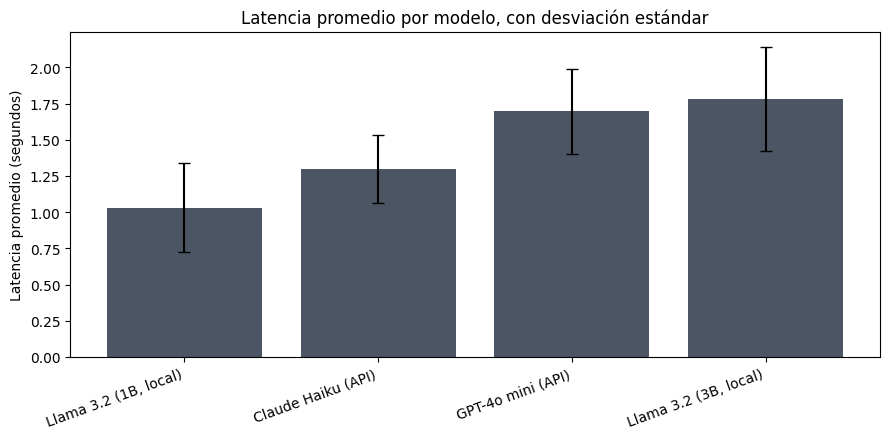

In [8]:

fig, ax = plt.subplots(figsize=(9, 4.5))
orden = resumen_por_modelo.sort_values("latencia_promedio_s")
ax.bar(orden["modelo"], orden["latencia_promedio_s"],
       yerr=orden["latencia_desv_s"], capsize=4, color="#4B5563")
ax.set_ylabel("Latencia promedio (segundos)")
ax.set_title("Latencia promedio por modelo, con desviación estándar")
ax.set_xticklabels(orden["modelo"], rotation=20, ha="right")
plt.tight_layout()
plt.show()


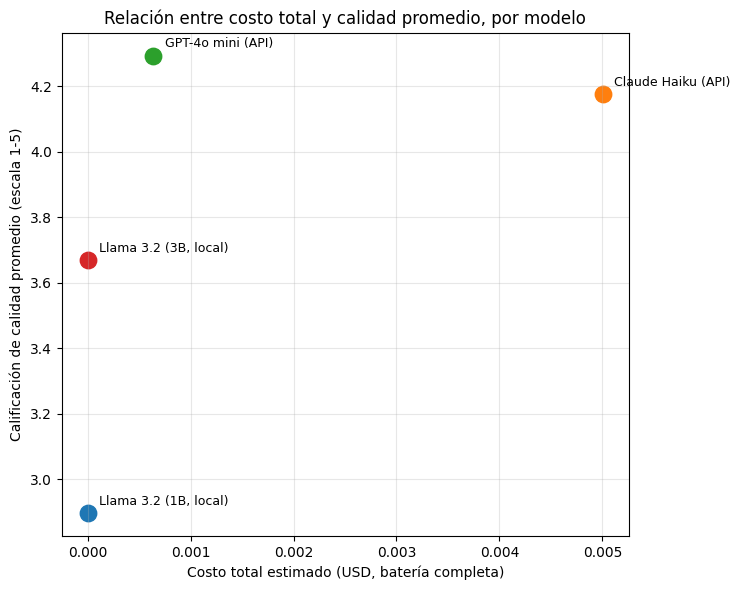

In [9]:

fig, ax = plt.subplots(figsize=(7.5, 6))
for _, fila in resumen_por_modelo.iterrows():
    ax.scatter(fila["costo_total_usd"], fila["calidad_promedio"], s=140)
    ax.annotate(fila["modelo"], (fila["costo_total_usd"], fila["calidad_promedio"]),
                textcoords="offset points", xytext=(8, 6), fontsize=9)
ax.set_xlabel("Costo total estimado (USD, batería completa)")
ax.set_ylabel("Calificación de calidad promedio (escala 1-5)")
ax.set_title("Relación entre costo total y calidad promedio, por modelo")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


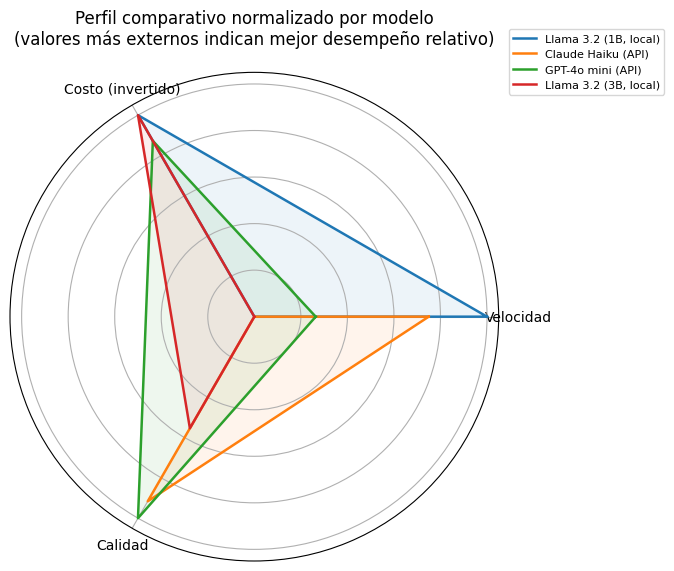

In [10]:

def normalizar(serie, invertir=False):
    minimo, maximo = serie.min(), serie.max()
    if maximo == minimo:
        normalizada = pd.Series([0.5] * len(serie), index=serie.index)
    else:
        normalizada = (serie - minimo) / (maximo - minimo)
    return 1 - normalizada if invertir else normalizada

radar_df = resumen_por_modelo.copy()
radar_df["velocidad_norm"] = normalizar(radar_df["tokens_por_s_promedio"])
radar_df["costo_norm"] = normalizar(radar_df["costo_promedio_usd"], invertir=True)
radar_df["calidad_norm"] = normalizar(radar_df["calidad_promedio"])

criterios = ["velocidad_norm", "costo_norm", "calidad_norm"]
etiquetas = ["Velocidad", "Costo (invertido)", "Calidad"]
n_criterios = len(criterios)

angulos = np.linspace(0, 2 * np.pi, n_criterios, endpoint=False).tolist()
angulos += angulos[:1]

fig, ax = plt.subplots(figsize=(7, 7), subplot_kw=dict(polar=True))
for _, fila in radar_df.iterrows():
    valores = [fila[c] for c in criterios]
    valores += valores[:1]
    ax.plot(angulos, valores, linewidth=1.8, label=fila["modelo"])
    ax.fill(angulos, valores, alpha=0.08)

ax.set_xticks(angulos[:-1])
ax.set_xticklabels(etiquetas)
ax.set_yticklabels([])
ax.set_title("Perfil comparativo normalizado por modelo\n(valores más externos indican mejor desempeño relativo)", pad=20)
ax.legend(loc="upper right", bbox_to_anchor=(1.35, 1.1), fontsize=8)
plt.tight_layout()
plt.show()



**Advertencia sobre la interpretación del gráfico de radar.** Los valores representados están normalizados dentro del conjunto de modelos evaluado en esta ejecución; no constituyen una escala absoluta y no son comparables con ejecuciones que utilicen un conjunto de modelos distinto.



---
## 8. Preguntas de análisis y discusión

Se sugiere que cada equipo de trabajo elabore una respuesta fundamentada, con base en los datos obtenidos, a las siguientes preguntas:

1. ¿Cuál modelo presenta la mejor relación entre costo y calidad para la batería de prompts evaluada? Justifique con las métricas correspondientes.
2. ¿Existe una categoría de tarea (matemática, código, resumen, razonamiento, conocimiento factual, creatividad) en la que las diferencias entre modelos sean particularmente pronunciadas? ¿A qué factores podría atribuirse dicha diferencia?
3. ¿El modelo de mayor latencia es también el de mayor calidad? En caso negativo, ¿qué implicancias tiene este resultado para la selección de un modelo en un contexto de producción con restricciones de tiempo de respuesta?
4. Considerando un volumen hipotético de 100.000 consultas mensuales equivalentes a la batería evaluada, ¿cuál sería el costo mensual proyectado para cada modelo? ¿Este cálculo modifica la recomendación inicial?
5. Proponga un caso de uso específico (por ejemplo, atención al cliente de alto volumen, asistencia en programación, análisis de documentos extensos) y justifique, con base en los datos recolectados, qué modelo del registro sería el más adecuado.
6. ¿Qué limitaciones posee la metodología empleada en este taller (tamaño de la batería de prompts, número de repeticiones, mecanismo de evaluación de calidad)? ¿Qué modificaciones propondría para una evaluación de mayor rigor?



---
## 9. Anexo: extensión de la infraestructura a proveedores adicionales

La incorporación de un nuevo proveedor a esta infraestructura requiere los siguientes pasos:

1. Definir una función `_consultar_<proveedor>(modelo, prompt)` que implemente la invocación correspondiente y retorne un diccionario con las claves `texto_respuesta`, `tokens_entrada` y `tokens_salida`.
2. Incorporar la nueva rama condicional dentro de la función `consultar_modelo`.
3. Añadir al `REGISTRO_MODELOS` las instancias de `ModeloLLM` correspondientes, especificando los costos de referencia vigentes según la documentación oficial del proveedor.

### Referencias de documentación oficial

- Ollama: ollama.com
- OpenAI: platform.openai.com/docs
- Anthropic: docs.anthropic.com
- Google AI: ai.google.dev

Se recomienda consultar estas fuentes para verificar precios, límites de tasa (rate limits) y disponibilidad de modelos vigentes al momento de la ejecución del taller, dado que dicha información está sujeta a actualizaciones periódicas por parte de cada proveedor.
